<a href="https://colab.research.google.com/github/gustavocoderjs/An-lise-de-Dados-/blob/main/ML_algoritmos_n_sup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning: teste de algoritmos não supervisionados**

## Exemplo de dataset - Marketing

## Kmeans

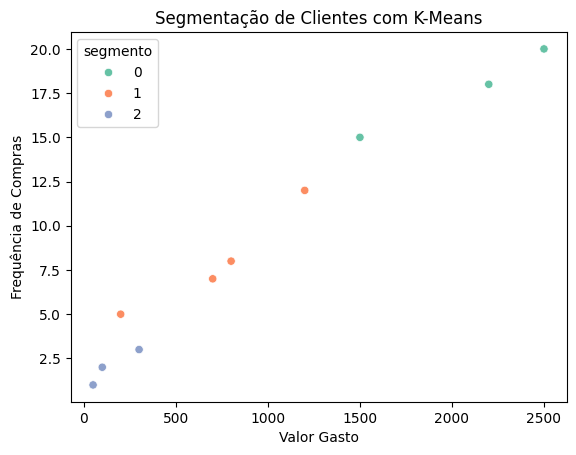

   cliente_id  segmento
0           1         1
1           2         0
2           3         2
3           4         0
4           5         1
5           6         2
6           7         1
7           8         2
8           9         0
9          10         1


In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'cliente_id': range(1, 11),
    'frequencia_compras': [5, 15, 2, 20, 8, 1, 12, 3, 18, 7],
    'valor_gasto': [200, 1500, 100, 2500, 800, 50, 1200, 300, 2200, 700],
    'dias_desde_ultima_compra': [10, 2, 30, 1, 7, 45, 3, 25, 2, 8]
}

df = pd.DataFrame(data)

features = ['frequencia_compras', 'valor_gasto', 'dias_desde_ultima_compra']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

kmeans = KMeans(n_clusters=3, random_state=42)
df['segmento'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(data=df, x='valor_gasto', y='frequencia_compras', hue='segmento', palette='Set2')
plt.title('Segmentação de Clientes com K-Means')
plt.xlabel('Valor Gasto')
plt.ylabel('Frequência de Compras')
plt.show()

print(df[['cliente_id', 'segmento']])

## PCA

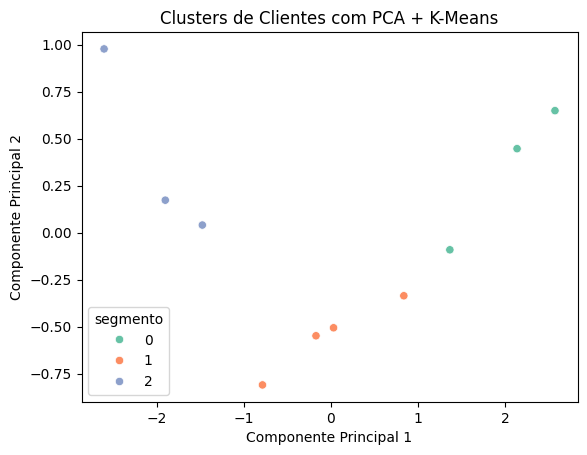

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='segmento', palette='Set2')
plt.title('Clusters de Clientes com PCA + K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

## Isolation Forest - para detecção de anomalia

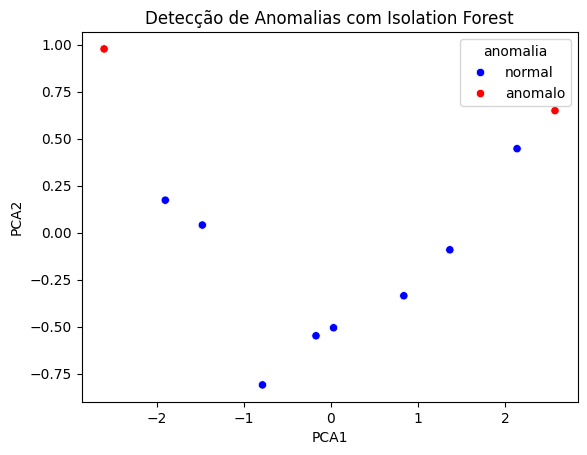

   cliente_id  frequencia_compras  valor_gasto  dias_desde_ultima_compra
3           4                  20         2500                         1
5           6                   1           50                        45


In [6]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.2, random_state=42)
df['anomalia'] = iso_forest.fit_predict(X_scaled)

df['anomalia'] = df['anomalia'].map({1: 'normal', -1: 'anomalo'})

sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='anomalia', palette={'normal': 'blue', 'anomalo': 'red'})
plt.title('Detecção de Anomalias com Isolation Forest')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

print(df[df['anomalia'] == 'anomalo'][['cliente_id', 'frequencia_compras', 'valor_gasto', 'dias_desde_ultima_compra']])
